In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ojaOdZy3uM9l0ri6psvN")
project = rf.workspace("vedant273ed").project("badminton-court-keypoint-dataset-eecdf-3mwwm")
version = project.version(2)
dataset = version.download("coco")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Badminton-Court-Keypoint-Dataset-2 in coco:: 100%|██████████| 6909/6909 [00:11<00:00, 615.20it/s]


In [12]:
import json
import os

DATASET_ROOT = r"E:\badminton prj\Z coor\Badminton-Court-Keypoint-Dataset-2"

annotation_path = os.path.join(DATASET_ROOT, "train", "_annotations.coco.json")

with open(annotation_path, "r") as f:
    data = json.load(f)

images = data["images"]
annotations = data["annotations"]

print("Total Images:", len(images))
print("Total Annotations:", len(annotations))

Total Images: 6039
Total Annotations: 11706


In [15]:
image_id_counts = {}

for ann in annotations:
    img_id = ann["image_id"]
    if img_id not in image_id_counts:
        image_id_counts[img_id] = 0
    image_id_counts[img_id] += 1

print("Max annotations per image:", max(image_id_counts.values()))

Max annotations per image: 20


In [13]:
print(len(images*8)==len(annotations))

False


In [16]:
# Pick first image id
first_image_id = images[0]["id"]

# Get all annotations for that image
anns_for_image = [ann for ann in annotations if ann["image_id"] == first_image_id]

print("Number of annotations for this image:", len(anns_for_image))

for i, ann in enumerate(anns_for_image):
    print("Annotation", i)
    print("Category ID:", ann["category_id"])
    print("Num keypoints:", ann.get("num_keypoints"))
    print("Length of keypoints list:", len(ann.get("keypoints", [])))
    print("----")

Number of annotations for this image: 2
Annotation 0
Category ID: 2
Num keypoints: None
Length of keypoints list: 12
----
Annotation 1
Category ID: 1
Num keypoints: None
Length of keypoints list: 12
----


In [ ]:
image_id_counts = {}

for ann in annotations:
    img_id = ann["image_id"]

    if img_id in image_id_counts:
        image_id_counts[img_id] += 1
    else:
        image_id_counts[img_id] = 1

distribution = {}

for count in image_id_counts.values():
    if count in distribution:
        distribution[count] += 1
    else:
        distribution[count] = 1

for key in sorted(distribution):
    print(key, "annotations →", distribution[key], "images")

1 annotations → 441 images
2 annotations → 5553 images
3 annotations → 33 images
20 annotations → 3 images


In [18]:
example_ids = {
    1: None,
    2: None,
    3: None,
    20: None
}

for img_id, count in image_id_counts.items():
    if count in example_ids and example_ids[count] is None:
        example_ids[count] = img_id

print(example_ids)

{1: 3, 2: 0, 3: 21, 20: 2932}


In [19]:
for count_type, img_id in example_ids.items():
    if img_id is None:
        continue

    print("\n==============================")
    print("IMAGE WITH", count_type, "ANNOTATIONS")
    print("Image ID:", img_id)

    # Get image info
    img_info = [img for img in images if img["id"] == img_id][0]
    print("File Name:", img_info["file_name"])
    print("Width:", img_info["width"])
    print("Height:", img_info["height"])

    # Get annotations for this image
    anns = [ann for ann in annotations if ann["image_id"] == img_id]

    print("Total annotations found:", len(anns))

    for i, ann in enumerate(anns):
        print("\n  Annotation", i)
        print("  Category ID:", ann["category_id"])
        print("  Keypoints length:", len(ann.get("keypoints", [])))
        print("  BBox:", ann.get("bbox"))


IMAGE WITH 1 ANNOTATIONS
Image ID: 3
File Name: HSBC-BWF-World-Tour-Finals-2022-AhsanSetiawan-INA-vs_-LiuOu-CHN-F_mp4-0028_jpg.rf.b017d40ac41df1919366dbd59b9879ab.jpg
Width: 640
Height: 360
Total annotations found: 1

  Annotation 0
  Category ID: 2
  Keypoints length: 12
  BBox: [142, 111, 357.799, 233.959]

IMAGE WITH 2 ANNOTATIONS
Image ID: 0
File Name: Men-s-Singles-Kodai-Naraoka-JPN-vs_-Loh-Kean-Yew-SGP-Badminton-2026-Pro-Badminton-MS-1080p-h264-_mp4-0297_jpg.rf.994cefc34ac03807a4b9179294b4584d.jpg
Width: 1920
Height: 1080
Total annotations found: 2

  Annotation 0
  Category ID: 2
  Keypoints length: 12
  BBox: [297, 366, 1447.143, 666.071]

  Annotation 1
  Category ID: 1
  Keypoints length: 12
  BBox: [497, 373, 1050, 296.071]

IMAGE WITH 3 ANNOTATIONS
Image ID: 21
File Name: Men-s-Singles-_-Jonatan-Christie-INA-vs_-Lakshya-Sen-IND-_-Badminton-2026_mp4-0362_jpg.rf.4ce59ec8e61a994d3c8e3b97ecdf5e48.jpg
Width: 1920
Height: 1080
Total annotations found: 3

  Annotation 0
  Categor

### Iska matlab in logo ne images ko annotate sahi se nai kiya hai kuch kuch 
### Hame vo category ke hi images chaiye hai jo 2 annotation wale hai (matlab 1 annotation contain karega court ke 4 keypoints and ek annotation contain karega net ke 4 key points)

## COCO image format me har ek key point rheta hai {x,y,visibility} ke format me 
## matlab suppose if we have 4 court corners as key points toh total apne pass 4*{len(x,y,visi)} that is 12(4*3) numbers rhete hai 

### hamme bass vo hi image chaiye jisme 2 category of annotation ho (court and net) and total = (4*3)+(4*3) = 24 nums ho 
4 keypoint court and 4 net ke 

In [25]:
import os
import cv2
import matplotlib.pyplot as plt

image_to_annotations = {}
SPLIT = "train"

for ann in annotations:
    img_id = ann["image_id"]
    if img_id not in image_to_annotations:
        image_to_annotations[img_id] = []
    image_to_annotations[img_id].append(ann)

def draw_keypoints(image, anns):

    for ann in anns:
        keypoints = ann.get("keypoints", [])

        for i in range(0, len(keypoints), 3):
            x = int(keypoints[i])
            y = int(keypoints[i + 1])
            v = keypoints[i + 2]

            if v > 0:
                cv2.circle(image, (x, y), 6, (0, 255, 0), -1)

    return image


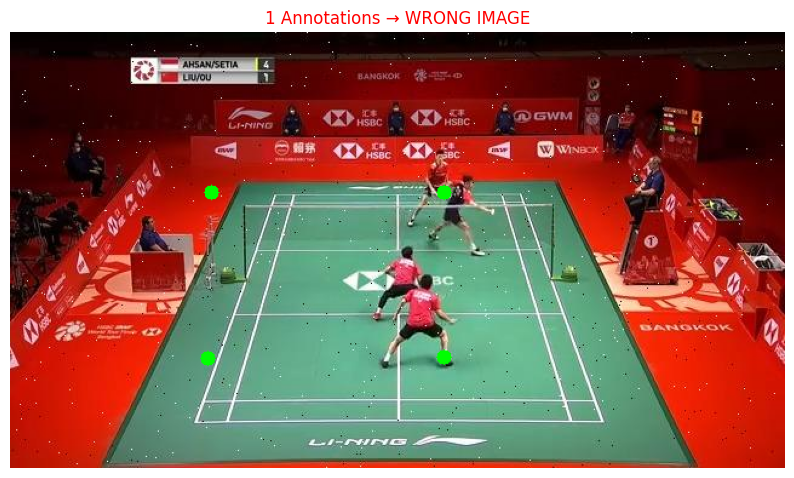

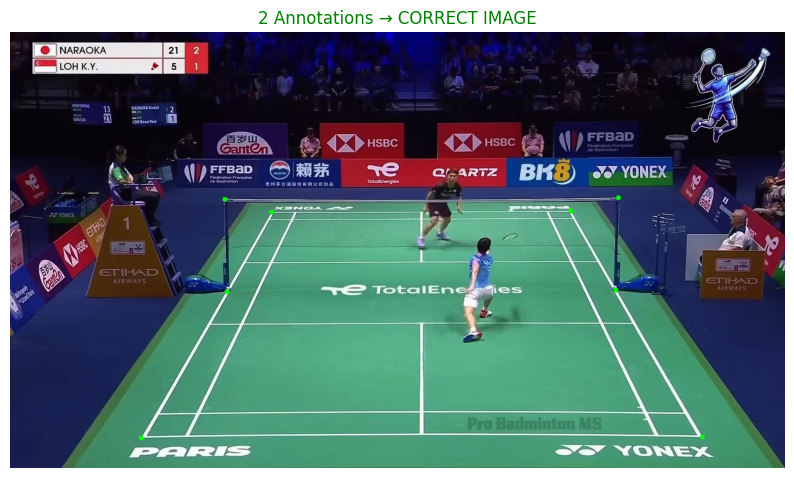

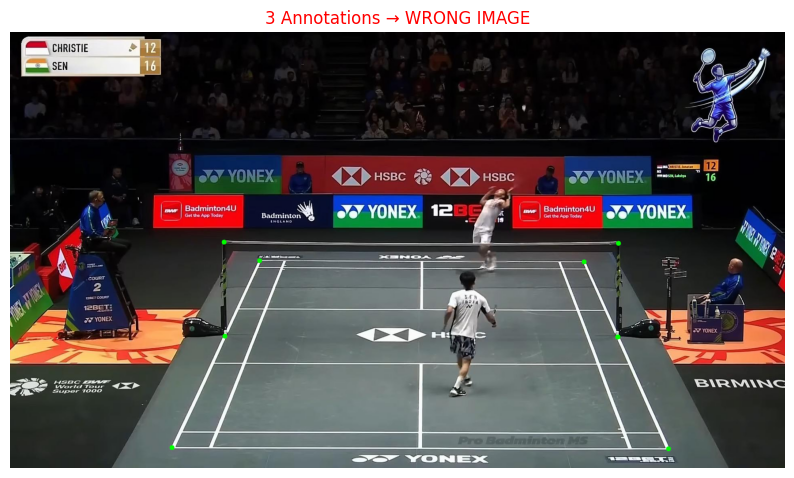

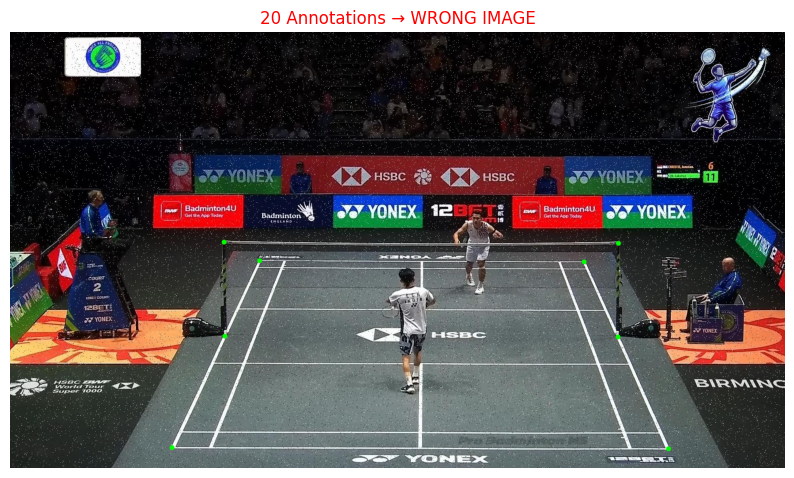

In [26]:
import json

for annotation_count, img_id in example_ids.items():

    if img_id is None:
        continue

    # Get image info
    img_info = next(img for img in images if img["id"] == img_id)
    img_path = os.path.join(DATASET_ROOT, SPLIT, img_info["file_name"])

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    anns = image_to_annotations[img_id]

    image = draw_keypoints(image.copy(), anns)

    # Decide label
    if annotation_count == 2:
        label = "CORRECT IMAGE"
        color = "green"
    else:
        label = "WRONG IMAGE"
        color = "red"

    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.title(f"{annotation_count} Annotations → {label}", color=color)
    plt.axis("off")
    plt.show()

Yes — visually they look the same(2 , 3 , 20 wale)

Court looks fine.
Keypoints look fine.

Because the problem is NOT visual.
The problem is STRUCTURAL.

DUplication create hua hai annotation me 

In [ ]:
import os
import json

DATASET_ROOT = r"E:\badminton prj\Z coor\Badminton-Court-Keypoint-Dataset-2"

for SPLIT in ["train", "valid", "test"]:

    print("\nCleaning split:", SPLIT)

    annotation_path = os.path.join(DATASET_ROOT, SPLIT, "_annotations.coco.json")

    with open(annotation_path, "r") as f:
        data = json.load(f)

    images = data["images"]
    annotations = data["annotations"]

    image_id_counts = {}

    for ann in annotations:
        img_id = ann["image_id"]

        if img_id in image_id_counts:
            image_id_counts[img_id] += 1
        else:
            image_id_counts[img_id] = 1

    valid_image_ids = set()

    for img_id, count in image_id_counts.items():
        if count == 2:
            valid_image_ids.add(img_id)

    for img in images:

        if img["id"] not in valid_image_ids:

            img_path = os.path.join(DATASET_ROOT, SPLIT, img["file_name"])

            if os.path.exists(img_path):
                os.remove(img_path)

    clean_images = []
    clean_annotations = []

    for img in images:
        if img["id"] in valid_image_ids:
            clean_images.append(img)

    for ann in annotations:
        if ann["image_id"] in valid_image_ids:
            clean_annotations.append(ann)

    data["images"] = clean_images
    data["annotations"] = clean_annotations

    # Save cleaned file
    clean_path = os.path.join(DATASET_ROOT, SPLIT, "_annotations_clean.coco.json")

    with open(clean_path, "w") as f:
        json.dump(data, f)

    print("Remaining images:", len(clean_images))

print("\nAll splits cleaned successfully.")


Cleaning split: train
Remaining images: 5553

Cleaning split: valid
Remaining images: 533

Cleaning split: test
Remaining images: 266

All splits cleaned successfully.
